In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [8]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "housing.csv"          # update path for a different dataset
TARGET_COL = "median_house_value" # target column name

LOAD DATASET

In [9]:
df = pd.read_csv(CSV_PATH)

In [10]:
print("DataFrame shape:", df.shape)

DataFrame shape: (20640, 10)


In [11]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


In [12]:
# basic dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [13]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Target column:", TARGET_COL)
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Target column: median_house_value
Numerical columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical columns: ['ocean_proximity']


In [14]:
# missing values analysis
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [15]:
# check presence of encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(20))

longitude
-118.310    162
-118.300    160
-118.290    148
-118.270    144
-118.320    142
-118.280    141
-118.350    140
-118.360    138
-118.190    135
-118.370    128
-118.250    128
-118.200    126
-118.140    125
-118.260    121
-118.130    121
-118.180    120
-118.340    119
-118.210    118
-118.150    116
-118.120    112
Name: count, dtype: int64
latitude
34.060    244
34.050    236
34.080    234
34.070    231
34.040    221
34.090    212
34.020    208
34.100    203
34.030    193
33.930    181
33.940    175
33.970    172
33.990    168
33.880    164
33.980    162
34.110    162
34.160    159
34.120    158
34.150    157
34.010    156
Name: count, dtype: int64
housing_median_age
52.000    1273
36.000     862
35.000     824
16.000     771
17.000     698
34.000     689
26.000     619
33.000     615
18.000     570
25.000     566
32.000     565
37.000     537
15.000     512
19.000     502
27.000     488
24.000     478
30.000     476
28.000     471
20.000     465
29.000     461
Name: coun

In [16]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
# df = df.drop_duplicates()
# print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 0


In [17]:
# descriptive stat
df[num_cols].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000,20640.000,20640.000,20640.000,20433.000,20640.000,20640.000,20640.000,20640.000
mean,-119.570,35.632,28.639,2635.763,537.871,1425.477,499.540,3.871,206855.817
std,2.004,2.136,12.586,2181.615,421.385,1132.462,382.330,1.900,115395.616
min,-124.350,32.540,1.000,2.000,1.000,3.000,1.000,0.500,14999.000
25%,-121.800,33.930,18.000,1447.750,296.000,787.000,280.000,2.563,119600.000
50%,-118.490,34.260,29.000,2127.000,435.000,1166.000,409.000,3.535,179700.000
75%,-118.010,37.710,37.000,3148.000,647.000,1725.000,605.000,4.743,264725.000
max,-114.310,41.950,52.000,39320.000,6445.000,35682.000,6082.000,15.000,500001.000


In [18]:
# descriptive stat
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,20640.000,2635.763,2181.615,2.000,1447.750,2127.000,3148.000,39320.000
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000
population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
households,20640.000,499.540,382.330,1.000,280.000,409.000,605.000,6082.000
median_income,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,20640.000,206855.817,115395.616,14999.000,119600.000,179700.000,264725.000,500001.000


DATA VISUALIZATION

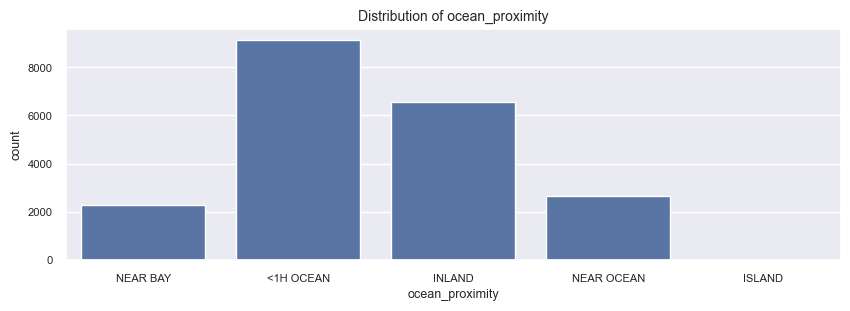

In [19]:
# countplot for categorical columns
for col in cat_cols:
    plt.figure(figsize=(10, 3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

In [20]:
for col in cat_cols:
    print(df[col].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


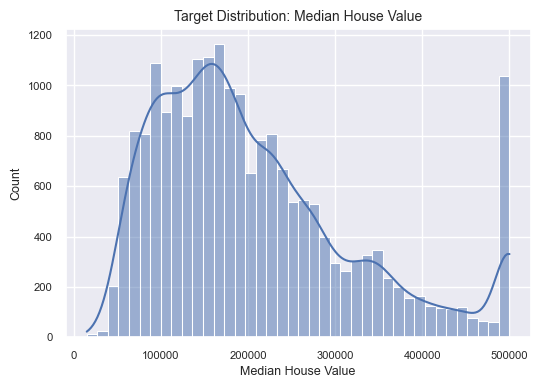

In [21]:
# target column distribution
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL], bins=40, kde=True)
plt.title("Target Distribution: Median House Value")
plt.xlabel("Median House Value")
plt.show()

In [22]:
df[TARGET_COL].value_counts()
# higher cap

median_house_value
500001.000    965
137500.000    122
162500.000    117
112500.000    103
187500.000     93
             ... 
352500.000      1
465000.000      1
457500.000      1
261200.000      1
307900.000      1
Name: count, Length: 3842, dtype: int64

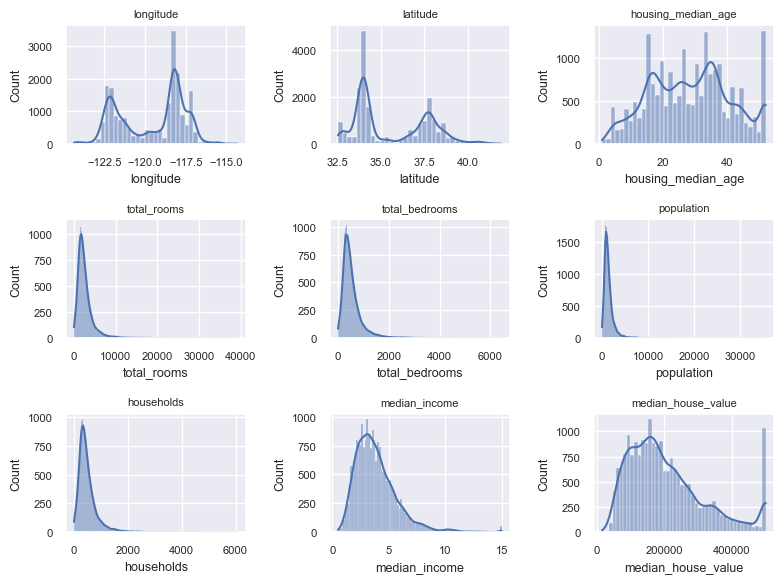

In [23]:
# histogram plot - distribution
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

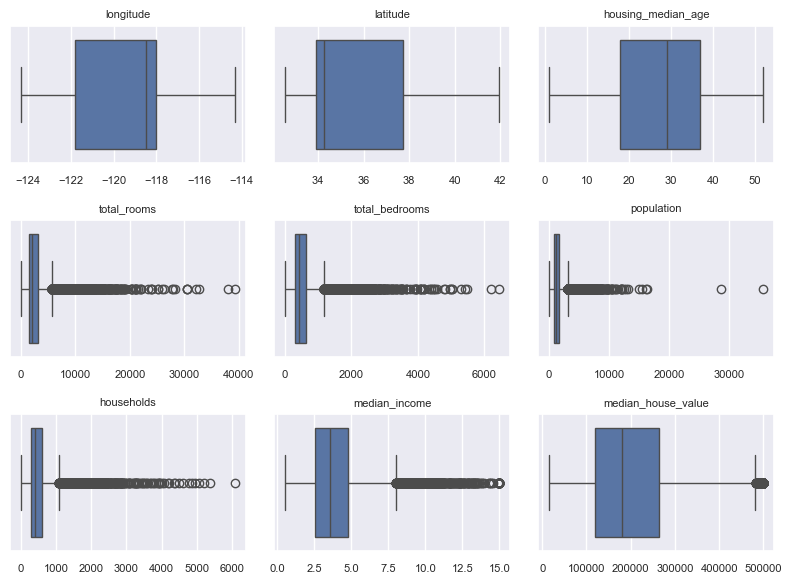

In [24]:
# outliers analysis - boxplot
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

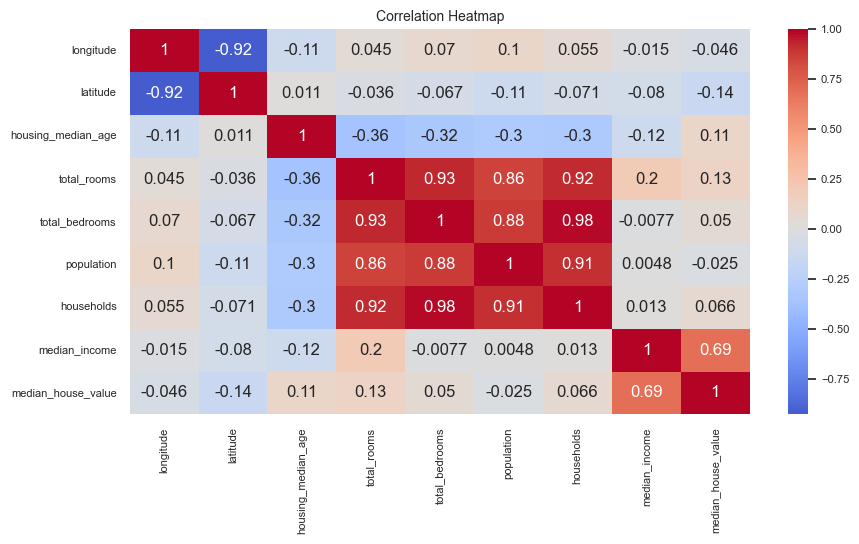

In [25]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(10, 5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [26]:
# Separate features & target
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# Column types
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Pipelines
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(16512, 9) (4128, 9)


In [28]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": HistGradientBoostingRegressor(random_state=42)
}

In [29]:
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"\n{name}")
    print("Train R2:", train_r2)
    print("Test R2:", test_r2)
    print("MAE:", mean_absolute_error(y_test, y_test_pred))
    print("RMSE:", root_mean_squared_error(y_test, y_test_pred))


Linear Regression
Train R2: 0.6496648627123224
Test R2: 0.6254382675296266
MAE: 50670.48923565362
RMSE: 70059.19333925015

Random Forest
Train R2: 0.9755650534559848
Test R2: 0.8172104989933294
MAE: 31628.40731104651
RMSE: 48941.70034309343

Gradient Boosting
Train R2: 0.8732128041976476
Test R2: 0.823750382394277
MAE: 32335.541845696836
RMSE: 48058.20235111429


In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__max_iter": [100, 200]
}

gb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

grid = GridSearchCV(
    gb_pipeline,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__max_iter': 200}


In [31]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("FINAL MODEL PERFORMANCE")
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

FINAL MODEL PERFORMANCE
R2: 0.8301716427073713
MAE: 31509.677986544193
RMSE: 47174.63345444922


In [32]:
import pickle

# Save model
pickle.dump(best_model, open("model.pkl", "wb"))

In [33]:
pickle.dump(best_model, open("full_pipeline.pkl", "wb"))

In [34]:
sample = X_test.iloc[0:1]

prediction = best_model.predict(sample)

print("Predicted Price:", prediction)
print("Actual Price:", y_test.iloc[0])

Predicted Price: [54776.9386905]
Actual Price: 47700.0


In [35]:
import pickle

pickle.dump(best_model, open("housing_model.pkl", "wb"))

In [36]:
import pickle
import os

if not os.path.exists("housing_model.pkl"):
    st.error("Model file not found! Please check path.")
else:
    model = pickle.load(open("housing_model.pkl", "rb"))

In [37]:
y_pred = best_model.predict(X_test)

In [38]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(comparison.head(10))

   Actual Price  Predicted Price
0     47700.000        54776.939
1     45800.000        72505.695
2    500001.000       453782.571
3    218600.000       239051.786
4    278000.000       282297.838
5    158700.000       163500.899
6    198200.000       299014.600
7    157500.000       195822.256
8    340000.000       295044.775
9    446600.000       475136.092


In [39]:
comparison["Error"] = comparison["Actual Price"] - comparison["Predicted Price"]
print(comparison.head(10))

   Actual Price  Predicted Price       Error
0     47700.000        54776.939   -7076.939
1     45800.000        72505.695  -26705.695
2    500001.000       453782.571   46218.429
3    218600.000       239051.786  -20451.786
4    278000.000       282297.838   -4297.838
5    158700.000       163500.899   -4800.899
6    198200.000       299014.600 -100814.600
7    157500.000       195822.256  -38322.256
8    340000.000       295044.775   44955.225
9    446600.000       475136.092  -28536.092


In [40]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 31509.677986544193
RMSE: 47174.63345444922
R2: 0.8301716427073713


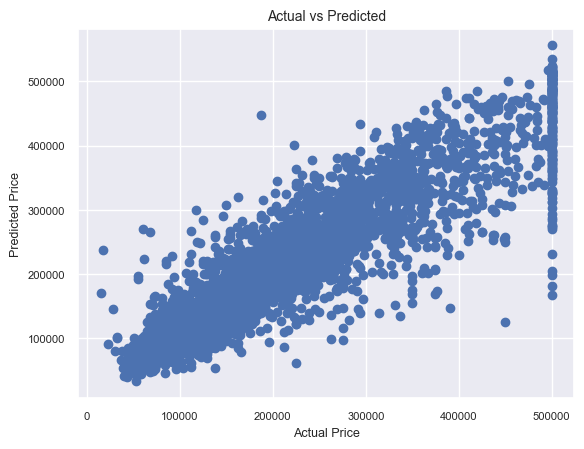

In [41]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

In [42]:
comparison["Percentage Error"] = (
    abs(comparison["Error"]) / comparison["Actual Price"]
) * 100

print(comparison.head(10))

   Actual Price  Predicted Price       Error  Percentage Error
0     47700.000        54776.939   -7076.939            14.836
1     45800.000        72505.695  -26705.695            58.309
2    500001.000       453782.571   46218.429             9.244
3    218600.000       239051.786  -20451.786             9.356
4    278000.000       282297.838   -4297.838             1.546
5    158700.000       163500.899   -4800.899             3.025
6    198200.000       299014.600 -100814.600            50.865
7    157500.000       195822.256  -38322.256            24.332
8    340000.000       295044.775   44955.225            13.222
9    446600.000       475136.092  -28536.092             6.390


In [ ]:
comparison.sort_values(by="Error", key=abs, ascending=False).head()